# Convolutional Neural Network Assignment

The task at hand involves classifying images of cats and dogs using a Convolutional Neural Network (CNN)

## Data Preparation

**Import Important Libraries**

In [1]:
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
! pip install -q kaggle

In [3]:
from google.colab import files

**Choose the kaggle.json file that you downloaded**

In [4]:
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"pradnyeshsawant","key":"c4be9efa03dde0f1f268aa969ba84e74"}'}

**Make directory named kaggle and copy kaggle.json file there.**

In [5]:
! mkdir ~/.kaggle

In [6]:
! cp kaggle.json ~/.kaggle/

**Change the permissions of the file.**

In [7]:
! chmod 600 ~/.kaggle/kaggle.json

In [8]:
#! kaggle datasets list

**Download Data**

In [9]:
! kaggle competitions download -c dogs-vs-cats --force

 97% 787M/812M [00:02<00:00, 269MB/s]
100% 812M/812M [00:02<00:00, 285MB/s]


**Unzip the Data**

In [10]:
! unzip -q dogs-vs-cats.zip
! unzip -q train.zip

In [11]:
# prompt: remove unzip files

#! rm dogs-vs-cats.zip
#! rm train.zip


In [12]:
# Image Data Generator
# images
#   |-cat
#       |-cat.1.jpg
#       |- ...
#   |-dog
#       |-dog.1.jpg
#       |- ...

In [13]:
# create master and category folders
os.mkdir('images')
os.mkdir('images/cat')
os.mkdir('images/dog')
os.mkdir('test')

In [14]:
# prompt: remove above created folders and its content

#!rm -rf images
#!rm -rf test

**Copy images from train data to cats and dogs folder**

In [15]:
os.listdir('train/')[0]

'dog.6662.jpg'

In [16]:
# transfer images from train folder to cat and dog folder.

from tqdm.auto import tqdm
import shutil

source = "train/"
dest_cat = "images/cat/"
dest_dog = "images/dog/"

for imageName in tqdm(os.listdir(source)):
  if imageName.startswith("cat"):
    shutil.copy(source + imageName, dest_cat)
  elif imageName.startswith("dog"):
    shutil.copy(source + imageName, dest_dog)


  0%|          | 0/25000 [00:00<?, ?it/s]

In [17]:
len(os.listdir(dest_cat)), len(os.listdir(dest_dog))

(12500, 12500)

In [18]:
len(os.listdir('test'))

0

**Select random test data and move it to the test folder**

In [19]:
# test data set
test_dog = np.random.choice(os.listdir('images/dog'), 500, replace=False)
test_cat = np.random.choice(os.listdir('images/cat'), 500, replace=False)

for imageName in test_dog:
  shutil.move(dest_dog + imageName, 'test/')
for imageName in test_cat:
  shutil.move(dest_cat + imageName, 'test/')

In [20]:
len(os.listdir('test'))

1000

**Organize the dataset into a structured directory format suitable for TensorFlow's ImageDataGenerator**

In [21]:
idg = ImageDataGenerator(horizontal_flip=True, rotation_range=30, rescale=1/255.0, validation_split=0.1)

## Data Augmetation and Preprocessing

In [22]:
batch_size = 64

In [23]:
train_idg = idg.flow_from_directory("images", target_size=(150, 150), batch_size=batch_size, subset="training")

Found 21600 images belonging to 2 classes.


In [24]:
val_idg = idg.flow_from_directory("images", target_size=(150, 150), batch_size=batch_size, subset="validation")

Found 2400 images belonging to 2 classes.


**Model Building**

In [25]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150,150, 3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.2))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.3))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.4))

model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.BatchNormalization())
#model.add(layers.Dropout(0.4))
model.add(layers.Dense(2, activation='softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 148, 148, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 72, 72, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 34, 34, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      18,940,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │           1,026 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,037,634 (72.62 MB)

 Trainable params: 19,036,162 (72.62 MB)

 Non-trainable params: 1,472 (5.75 KB)

## Training

**Compile the model**

In [27]:
sgd = optimizers.SGD(learning_rate=0.01)
model.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])

In [28]:
! pip install livelossplot

from livelossplot import PlotLossesKeras

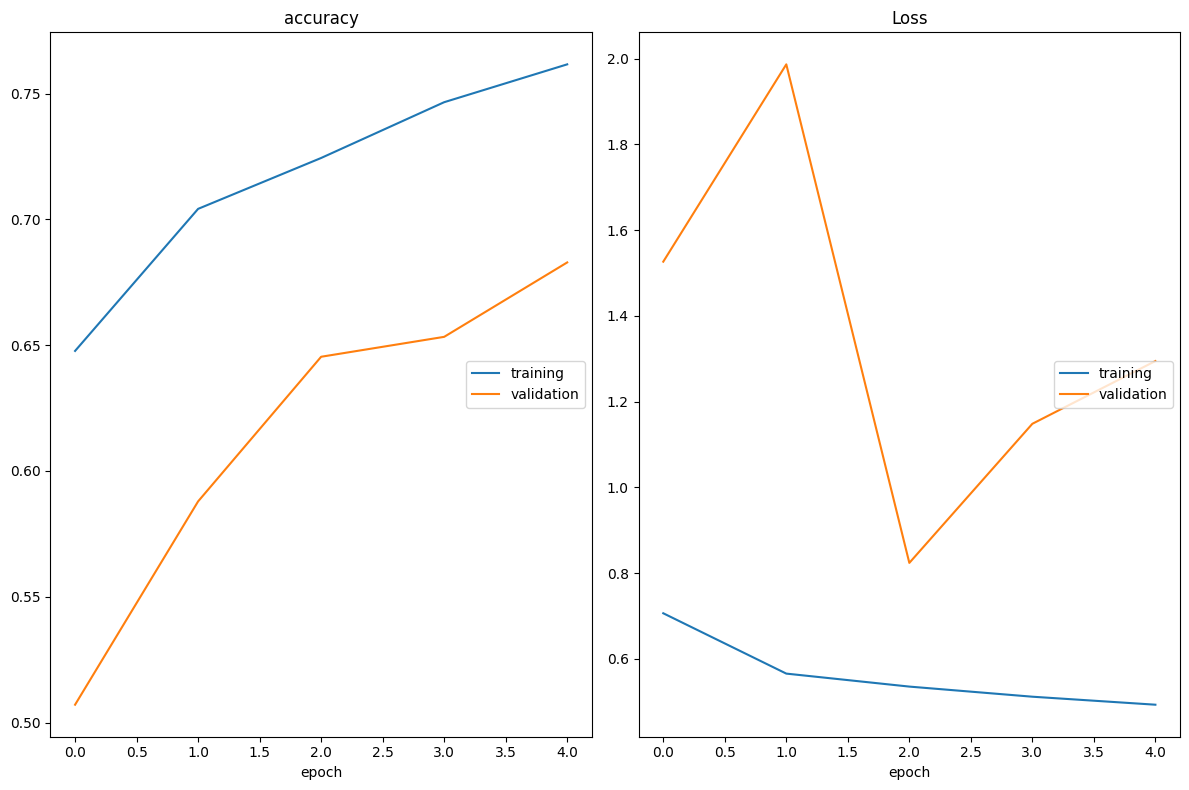

accuracy
	training         	 (min:    0.648, max:    0.762, cur:    0.762)
	validation       	 (min:    0.507, max:    0.683, cur:    0.683)
Loss
	training         	 (min:    0.493, max:    0.707, cur:    0.493)
	validation       	 (min:    0.824, max:    1.987, cur:    1.295)
338/338 ━━━━━━━━━━━━━━━━━━━━ 202s 450ms/step - accuracy: 0.7606 - loss: 0.4954 - val_accuracy: 0.6829 - val_loss: 1.2949


In [29]:
model.fit(train_idg, epochs=5, batch_size=batch_size, validation_data=val_idg, verbose=1, callbacks=[PlotLossesKeras()])

In [30]:
test_image = "test/dog.1000.jpg"
test_image

'test/dog.1000.jpg'

In [31]:
os.listdir('test')

['cat.1968.jpg',
 'dog.3845.jpg',
 'cat.5801.jpg',
 'dog.8779.jpg',
 'cat.10228.jpg',
 'dog.9015.jpg',
 'dog.2874.jpg',
 'cat.6813.jpg',
 'cat.1490.jpg',
 'dog.7948.jpg',
 'dog.5666.jpg',
 'cat.11324.jpg',
 'dog.4825.jpg',
 'dog.237.jpg',
 'cat.9138.jpg',
 'dog.6537.jpg',
 'cat.4164.jpg',
 'dog.2212.jpg',
 'cat.11176.jpg',
 'cat.9592.jpg',
 'dog.8382.jpg',
 'cat.3479.jpg',
 'cat.4850.jpg',
 'dog.10024.jpg',
 'cat.10123.jpg',
 'cat.3950.jpg',
 'dog.12251.jpg',
 'cat.4174.jpg',
 'dog.9862.jpg',
 'cat.2412.jpg',
 'cat.3321.jpg',
 'dog.5544.jpg',
 'dog.11735.jpg',
 'cat.8360.jpg',
 'dog.5923.jpg',
 'dog.11092.jpg',
 'dog.8740.jpg',
 'dog.11309.jpg',
 'cat.4014.jpg',
 'cat.3651.jpg',
 'dog.8339.jpg',
 'dog.5601.jpg',
 'cat.4353.jpg',
 'cat.10961.jpg',
 'cat.122.jpg',
 'dog.10770.jpg',
 'cat.5405.jpg',
 'dog.7832.jpg',
 'cat.5142.jpg',
 'cat.5271.jpg',
 'cat.103.jpg',
 'dog.2093.jpg',
 'cat.1130.jpg',
 'dog.10538.jpg',
 'dog.546.jpg',
 'dog.12264.jpg',
 'dog.11617.jpg',
 'cat.8881.jpg',
 'do

(1, 150, 150, 3)

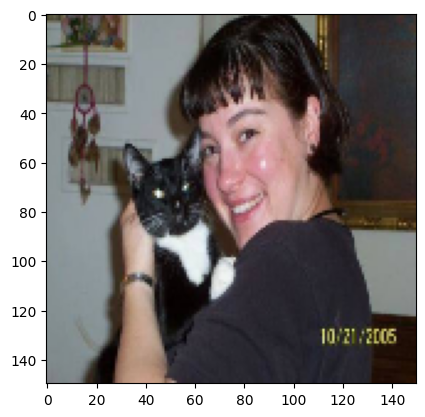

In [33]:
# Image in test
import cv2

test_image = "test/cat.7480.jpg"
test_image = cv2.imread(test_image)
test_image = cv2.resize(test_image, (150, 150))
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
plt.imshow(test_image)
test_image = np.expand_dims(test_image, axis=0)
test_image = test_image/255.0
test_image.shape

In [34]:
model.predict(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 799ms/step


array([[0.12957168, 0.87042826]], dtype=float32)

In [35]:
train_idg.class_indices

{'cat': 0, 'dog': 1}

In [37]:
test_result = {}
for imageName in tqdm(os.listdir('test/')):
  test_image = "test/" + imageName
  test_image = cv2.imread(test_image)
  test_image = cv2.resize(test_image, (150, 150))
  test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
  test_image = np.expand_dims(test_image, axis=0)
  test_image = test_image/255.0
  result = model.predict(test_image)
  test_result[imageName] = result

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━

In [38]:
test_result

{'cat.1968.jpg': array([[0.8280582, 0.1719418]], dtype=float32),
 'dog.3845.jpg': array([[9.9995565e-01, 4.4303455e-05]], dtype=float32),
 'cat.5801.jpg': array([[0.64433193, 0.35566804]], dtype=float32),
 'dog.8779.jpg': array([[0.02529622, 0.9747038 ]], dtype=float32),
 'cat.10228.jpg': array([[0.29941908, 0.7005809 ]], dtype=float32),
 'dog.9015.jpg': array([[0.43930063, 0.5606994 ]], dtype=float32),
 'dog.2874.jpg': array([[0.80342996, 0.19657008]], dtype=float32),
 'cat.6813.jpg': array([[9.9994946e-01, 5.0569190e-05]], dtype=float32),
 'cat.1490.jpg': array([[0.991454, 0.008546]], dtype=float32),
 'dog.7948.jpg': array([[0.00116399, 0.998836  ]], dtype=float32),
 'dog.5666.jpg': array([[0.00266664, 0.99733335]], dtype=float32),
 'cat.11324.jpg': array([[0.09734327, 0.9026567 ]], dtype=float32),
 'dog.4825.jpg': array([[0.9630642 , 0.03693582]], dtype=float32),
 'dog.237.jpg': array([[0.31883392, 0.6811661 ]], dtype=float32),
 'cat.9138.jpg': array([[0.4639733, 0.5360267]], dtype=

In [39]:
X_test = []
for imageName in tqdm(os.listdir('test/')):
  test_image = "test/" + imageName
  test_image = cv2.imread(test_image)
  test_image = cv2.resize(test_image, (150, 150))
  test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
  test_image = test_image / 255.0
  X_test.append(test_image)
X_test = np.array(X_test)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [40]:
X_test.shape

(1000, 150, 150, 3)

## **Predictions**

In [41]:
prediction = model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


In [43]:
prediction[1]

array([9.9995565e-01, 4.4303964e-05], dtype=float32)